# Multilayer Perceptron from Scratch

A multilayer perceptron is a stack of affine maps with a non-linear function between them. Each
layer multiplies its input by a weight matrix, adds a bias, and passes the result through an
activation. The last layer produces one score per class and a softmax turns those scores into
probabilities.

This notebook uses the same data as `2d_cnn_from_scratch.ipynb`: the UCI handwritten digits, 5,620
images of 8x8 pixels. That is deliberate. The MLP receives each image as 64 unordered numbers, so
it has no idea that pixel 9 sits directly below pixel 1. The convolutional network does. Both
numbers the CNN reached - **97.9%** test accuracy from **1,610** weights - are quoted again at the
end against what this network manages, because the interesting comparison is not which one wins on
accuracy but what each of them pays for it.

The network built here is:

```
64 pixels
  -> affine 64 -> 64, ReLU
  -> affine 64 -> 32, ReLU
  -> affine 32 -> 10
  -> softmax
```

Forward pass, backward pass and the weight updates are all written out. A finite-difference check
confirms the derivatives before any training happens, and the notebook then tests three claims
empirically: that removing the activation collapses the whole stack to a single linear layer, that
widening the hidden layer helps only up to a point, and that each extra hidden layer helps by a
shrinking amount.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green = '#2a78d6', '#eb6834', '#1baf7a'

notebook_start = time.time()

## Loading the data

`fetch_ucirepo(id=80)` downloads 5,620 handwritten digits. Each row is 64 numbers holding an 8x8
image flattened out, with pixel values from 0 to 16, so dividing by 16 puts every feature in
$[0, 1]$. The ten digits are close to evenly represented, roughly 10% each, so accuracy is a fair
measure and the baseline to beat is 10%.

`X_all` keeps the flat 64-column form the network works with. `X_images` is the same data reshaped
to 8x8 and is only used for drawing. The shuffle uses seed 0 and the split is 80/20, matching the
CNN notebook exactly so the two accuracies are measured on the same test digits.

In [2]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float) / 16.0
y_all = digits.data.targets.values.ravel()
X_images = X_all.reshape(-1, 8, 8)

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

train_idx, test_idx = order[:split], order[split:]
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print('features:', X_all.shape, ' pixel range:', X_all.min(), 'to', X_all.max())
print('train:', X_train.shape, ' test:', X_test.shape)
print('class counts:', np.bincount(y_all))

features: (5620, 64)  pixel range: 0.0 to 1.0
train: (4496, 64)  test: (1124, 64)
class counts: [554 571 557 572 568 558 558 566 554 562]


The cell below draws ten training images with their labels. The network never sees them arranged
like this - it sees each one as a row of 64 numbers in a fixed order.

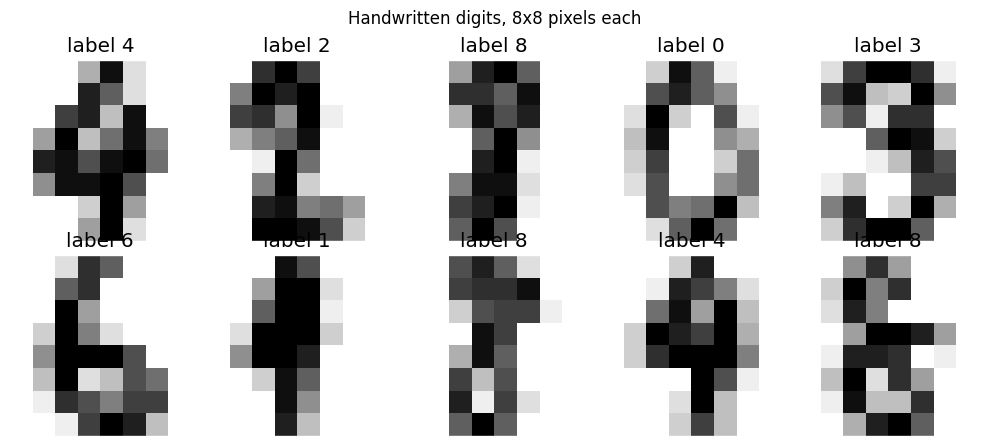

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, index in zip(ax.ravel(), range(10)):
    a.imshow(X_images[train_idx[index]], cmap='gray_r')
    a.set_title(f'label {y_train[index]}')
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

plt.suptitle('Handwritten digits, 8x8 pixels each')
plt.tight_layout()
plt.show()

## The forward pass

Write $\mathbf{a}^{(0)} = \mathbf{x}$ for the input. Layer $l$ computes a weighted sum and passes
it through an activation $g$:

$$\mathbf{z}^{(l)} = W^{(l)\top}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}, \qquad
\mathbf{a}^{(l)} = g(\mathbf{z}^{(l)})$$

with $W^{(l)}$ of shape (units in $l-1$) x (units in $l$). The code stores exactly that shape and
works on a whole batch of rows at once, so the transpose disappears and the line reads
`z = a @ W + b`, where `a` has one sample per row.

The activation is the rectifier:

$$g(z) = \max(0, z), \qquad g'(z) = \begin{cases} 1 & z > 0 \\ 0 & z < 0 \end{cases}$$

It is not differentiable at $z = 0$; the code uses `z > 0`, which takes the derivative there to be
0. That choice is arbitrary and never matters in practice, because a pre-activation hitting exactly
zero is a measure-zero event in floating point.

The output layer has no ReLU. Its 10 scores go through the softmax

$$p_k = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}}$$

which is non-negative and sums to one, so it can be read as a distribution over the digits. The
largest score before the softmax is still the largest probability after it, so prediction is just
`argmax`. The implementation subtracts the row maximum first, which leaves $p$ unchanged - the
constant cancels between numerator and denominator - but stops `exp` overflowing.

The loss over $n$ samples is the cross-entropy of the true label against those probabilities:

$$J = -\frac{1}{n}\sum_{i=1}^{n} \log p_{i, y_i}$$

Only the probability given to the correct class appears. Driving $J$ down means pushing that one
probability towards 1, which by the sum-to-one constraint pushes the other nine down.

## Why the non-linearity is not optional

Take two affine layers with the activation removed:

$$W_2^\top\!\left(W_1^\top\mathbf{x} + \mathbf{b}_1\right) + \mathbf{b}_2
= \left(W_2^\top W_1^\top\right)\mathbf{x} + \left(W_2^\top\mathbf{b}_1 + \mathbf{b}_2\right)
= W'^\top\mathbf{x} + \mathbf{b}'$$

The result is another affine map. The same collapse repeats for any number of layers, so a stack of
$L$ linear layers can represent nothing that a single linear layer cannot. Depth without an
activation buys parameters and training time and no extra expressive power at all. This is checked
empirically further down by training the identical architecture with `activation=False`.

$g$ breaks that collapse. ReLU is piecewise linear, and a network of them carves the input space
into regions with a different linear map on each, which is a far larger family of functions than a
single hyperplane.

## The backward pass

Training needs $\partial J/\partial W^{(l)}$ and $\partial J/\partial \mathbf{b}^{(l)}$ for every
layer. Computing each one separately would repeat almost all of the work, because the derivative
for an early layer contains the derivative for every layer after it. Backpropagation computes them
once, from the output backwards.

Define the error signal at layer $l$ as the derivative of the loss with respect to that layer's
pre-activation:

$$\boldsymbol\delta^{(l)} = \frac{\partial J}{\partial \mathbf{z}^{(l)}}$$

**Output layer.** With $\mathbf{p} = \mathrm{softmax}(\mathbf{z}^{(L)})$ and one-hot label
$\mathbf{y}$, the loss for one sample is $J = -\sum_k y_k \log p_k$. Differentiating the softmax
gives $\partial p_k/\partial z_j = p_k(\delta_{kj} - p_j)$, so

$$\frac{\partial J}{\partial z_j} = -\sum_k \frac{y_k}{p_k}\, p_k(\delta_{kj} - p_j)
= -y_j + p_j \sum_k y_k = p_j - y_j$$

using $\sum_k y_k = 1$. So

$$\boldsymbol\delta^{(L)} = \mathbf{p} - \mathbf{y}$$

The softmax and the cross-entropy are differentiated together, and everything cancels down to the
difference between what the network predicted and what was true. This is the same expression the
logistic regression notebook arrives at, and the same one the CNN notebook starts its backward pass
from.

**Every other layer.** $\mathbf{z}^{(l)}$ affects the loss only through $\mathbf{z}^{(l+1)}$, and
$z^{(l+1)}_j = \sum_i W^{(l+1)}_{ij} g(z^{(l)}_i) + b^{(l+1)}_j$. The chain rule over that one path
gives

$$\delta^{(l)}_i = \sum_j \frac{\partial J}{\partial z^{(l+1)}_j}
\frac{\partial z^{(l+1)}_j}{\partial z^{(l)}_i}
= \sum_j \delta^{(l+1)}_j W^{(l+1)}_{ij} \, g'(z^{(l)}_i)$$

which in vector form is the recurrence

$$\boldsymbol\delta^{(l)} = \left(W^{(l+1)}\boldsymbol\delta^{(l+1)}\right) \odot g'(\mathbf{z}^{(l)})$$

where $\odot$ is elementwise. The error is pushed back through the same weights that carried the
signal forward, then masked wherever the ReLU was off - a unit that output zero had no influence on
the loss and receives no gradient.

**Parameters.** Since $\partial z^{(l)}_j / \partial W^{(l)}_{ij} = a^{(l-1)}_i$ and
$\partial z^{(l)}_j / \partial b^{(l)}_j = 1$,

$$\frac{\partial J}{\partial W^{(l)}} = \mathbf{a}^{(l-1)}\boldsymbol\delta^{(l)\top},
\qquad \frac{\partial J}{\partial \mathbf{b}^{(l)}} = \boldsymbol\delta^{(l)}$$

an outer product of the layer's input with its error. Over a batch this becomes
`activations[l].T @ delta`, which sums that outer product across the rows in one matrix product.

This is why the forward pass has to keep `self.activations` and `self.zs`: the gradient for layer
$l$ needs the input that layer saw and the pre-activation it produced.

## The chain rule, layer by layer

The animation below is the recurrence above, drawn. Backpropagation is not a separate algorithm -
it is the chain rule applied to a composition of functions, arranged so nothing is computed twice.

The output error is startlingly simple,

$$\delta^{(L)} = p - y$$

and that is not a coincidence: the softmax derivative and the cross-entropy derivative cancel,
leaving the raw difference. The animation shows that cancellation rather than asserting it.

From there each layer's error comes from the one above it:

$$\delta^{(l)} = \left(W^{(l+1)\top}\delta^{(l+1)}\right) \odot \sigma'\!\left(z^{(l)}\right)$$

Both factors have a job. Transposing $W$ sends the error back along the same edges it came forward
on. The elementwise $\sigma'$ term gates it by whether the unit was active - with ReLU that gate
is literally 0 or 1, so some units pass the error along and others block it completely.

The parameter gradient that falls out, $\partial J/\partial W^{(l)} = \delta^{(l)} a^{(l-1)\top}$,
is an outer product: the gradient for a weight is the error at its destination times the
activation at its source. Each $\delta$ is computed once and reused for every weight feeding that
unit, which is why one backward sweep costs about the same as one forward sweep instead of being
redone per parameter.

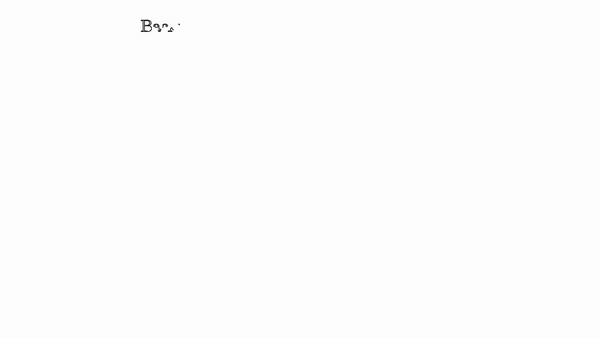

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/backprop_chain.gif')

## Initialisation

The weights cannot start at zero. Every unit in a layer would then compute the same thing, receive
the same gradient and stay identical forever - the layer would behave as a single unit no matter
how wide it is. Random values break that symmetry, but the scale of them matters.

If the entries of $W^{(l)}$ are drawn with variance $\sigma^2$ and the layer has $n_{\text{in}}$
inputs, the variance of $z$ is about $n_{\text{in}}\sigma^2$ times the variance of the input. Left
unchecked that factor compounds across layers: slightly too small and the signal shrinks towards
zero layer by layer, slightly too large and it explodes, and the gradients flowing back do the same
thing in reverse. He initialisation sets

$$\sigma = \sqrt{\frac{2}{n_{\text{in}}}}$$

The factor of 2 is there because ReLU discards the negative half of its input, roughly halving the
variance, so the weights are scaled up to compensate. With it, activations keep a similar spread at
every depth and training starts from a sensible place instead of a saturated or numerically dead
one.

## The class

`Neural_Network` takes a list such as `[64, 64, 32, 10]` and builds one weight matrix and one bias
vector per consecutive pair, so the list alone fixes the architecture. `activation=False` skips the
ReLU, which is used later for the linear-collapse experiment.

`forward` walks the layers in order, storing every input in `self.activations` and every
pre-activation in `self.zs`, and applies softmax at the last layer instead of ReLU.

`backward` implements the recurrence above as a loop running from the last layer to the first. It
returns the gradients rather than applying them, so the gradient check can compare them directly.
`step` subtracts `learning_rate` times each gradient.

`fit` runs mini-batch SGD: each epoch reshuffles the training rows, walks them in batches of
`batch_size`, and calls `forward`, `backward` and `step` on each batch. Loss and accuracy on both
sets are appended to `self.history` after every epoch.

In [4]:
def softmax(scores):
    # subtract the row maximum first so exp cannot overflow
    e = np.exp(scores - scores.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def cross_entropy(probs, y):
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()


class Neural_Network:
    def __init__(self, layer_sizes, learning_rate=0.1, activation=True, seed=0):
        r = np.random.default_rng(seed)

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.activation = activation
        self.weights = []
        self.biases = []
        self.history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            # He initialisation: sqrt(2 / fan_in)
            self.weights.append(r.normal(0, np.sqrt(2 / fan_in), (fan_in, fan_out)))
            self.biases.append(np.zeros(fan_out))

    def forward(self, X):
        self.activations = [X]
        self.zs = []
        last = len(self.weights) - 1
        a = X

        for i in range(len(self.weights)):
            z = a @ self.weights[i] + self.biases[i]
            self.zs.append(z)

            if i == last:
                a = softmax(z)
            elif self.activation:
                a = np.maximum(0, z)
            else:
                a = z

            self.activations.append(a)

        return a

    def backward(self, probs, y):
        n = len(y)

        # softmax and cross-entropy differentiated together: p - y
        delta = probs.copy()
        delta[np.arange(n), y] -= 1
        delta /= n

        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        for i in range(len(self.weights) - 1, -1, -1):
            grads_w[i] = self.activations[i].T @ delta
            grads_b[i] = delta.sum(axis=0)

            if i > 0:
                delta = delta @ self.weights[i].T
                if self.activation:
                    delta = delta * (self.zs[i - 1] > 0)

        return grads_w, grads_b

    def step(self, grads_w, grads_b):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grads_w[i]
            self.biases[i] -= self.learning_rate * grads_b[i]

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

    def score(self, X, y):
        probs = self.forward(X)
        return cross_entropy(probs, y), (probs.argmax(axis=1) == y).mean()

    def weight_count(self):
        return sum(w.size for w in self.weights) + sum(b.size for b in self.biases)

    def fit(self, X, y, X_test, y_test, epochs=40, batch_size=32, seed=0, report_every=0):
        for epoch in range(epochs):
            batch_order = np.random.default_rng(seed + epoch).permutation(len(X))

            for s in range(0, len(batch_order), batch_size):
                batch = batch_order[s:s + batch_size]
                probs = self.forward(X[batch])
                grads_w, grads_b = self.backward(probs, y[batch])
                self.step(grads_w, grads_b)

            tl, ta = self.score(X, y)
            vl, va = self.score(X_test, y_test)
            self.history['train_loss'].append(tl)
            self.history['test_loss'].append(vl)
            self.history['train_acc'].append(ta)
            self.history['test_acc'].append(va)

            if report_every and (epoch + 1) % report_every == 0:
                print(f'epoch {epoch+1:3d}  train loss {tl:.4f} acc {ta:.4f}'
                      f'  |  test loss {vl:.4f} acc {va:.4f}')

        return self

## Checking the derivatives

A wrong backward pass raises no error. The network simply trains badly, or trains slightly worse
than it should, which is easy to mistake for a bad learning rate. The only way to be sure is to
compare the analytic gradient against the loss itself.

The definition of the derivative gives a way to measure it: nudge one weight by $\varepsilon$ in
each direction and take the central difference

$$\frac{\partial J}{\partial w} \approx \frac{J(w + \varepsilon) - J(w - \varepsilon)}{2\varepsilon}$$

which is accurate to $O(\varepsilon^2)$, unlike the one-sided version. With
$\varepsilon = 10^{-5}$ and double precision the two sides should agree to roughly eight decimal
places - closer than that is limited by floating-point cancellation in the numerator, further apart
means a real disagreement.

The cell builds a small network, takes one batch, and computes `grads_w` and `grads_b` from
`backward`. It then picks the four entries of each layer with the largest gradient magnitude, since
comparing entries whose gradient is near zero proves nothing, and prints the analytic value against
the measured slope for each.

In [5]:
check_net = Neural_Network([64, 12, 8, 10], learning_rate=0.0, seed=3)
Xb, yb = X_train[:16], y_train[:16]

probs = check_net.forward(Xb)
grads_w, grads_b = check_net.backward(probs, yb)

eps = 1e-5


def measured_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = cross_entropy(check_net.forward(Xb), yb)
    param[index] = original - eps
    down = cross_entropy(check_net.forward(Xb), yb)
    param[index] = original
    return (up - down) / (2 * eps)


print(f'{"parameter":22s} {"from backward":>16s} {"measured":>16s} {"difference":>13s}')

for layer in range(len(check_net.weights)):
    g = grads_w[layer]
    # the four weights in this layer with the largest gradient
    flat = np.argsort(np.abs(g).ravel())[::-1][:4]
    for f in flat:
        index = np.unravel_index(f, g.shape)
        slope = measured_slope(check_net.weights[layer], index)
        print(f'W{layer} {str(index):18s} {g[index]:16.8f} {slope:16.8f} {abs(g[index]-slope):13.2e}')

for layer in range(len(check_net.biases)):
    g = grads_b[layer]
    index = int(np.argmax(np.abs(g)))
    slope = measured_slope(check_net.biases[layer], (index,))
    print(f'b{layer} {str((index,)):18s} {g[index]:16.8f} {slope:16.8f} {abs(g[index]-slope):13.2e}')

parameter                 from backward         measured    difference
W0 (28, 7)                  0.32855638       0.32855638      2.20e-11
W0 (35, 7)                  0.31755522       0.31755522      8.44e-13
W0 (50, 7)                  0.31738615       0.31738615      3.39e-11
W0 (59, 7)                  0.31445903       0.31445903      3.30e-12
W1 (10, 0)                  0.34758324       0.34758324      3.23e-11
W1 (7, 0)                   0.17530442       0.17530442      2.83e-11
W1 (10, 3)                  0.16125148       0.16125148      1.77e-11
W1 (5, 0)                   0.15659678       0.15659678      2.79e-12
W2 (0, 8)                  -0.17493379      -0.17493379      7.66e-12
W2 (0, 2)                  -0.16804952      -0.16804952      1.61e-13
W2 (0, 7)                   0.15942357       0.15942357      8.91e-12
W2 (0, 0)                   0.07219912       0.07219912      4.38e-12
b0 (7,)                     0.31549764       0.31549764      3.44e-11
b1 (0,)            

Every pair agrees to eight decimal places, so the hand-written backward pass matches what the loss
actually does when the weight moves. The remaining disagreement is the truncation error of the
finite difference, not a mistake in the derivation.

## Training

`net` is the `[64, 64, 32, 10]` network. It trains for 40 epochs at a learning rate of 0.1 with
batches of 32, which is 141 gradient steps per epoch.

Mini-batch SGD estimates the gradient of the full training loss from 32 samples at a time. That
estimate is noisy, but it is 141 times cheaper per step than using all 4,496 rows, and the noise is
not purely a cost - it stops the parameters settling into the first flat spot they meet.

In [6]:
net = Neural_Network([64, 64, 32, 10], learning_rate=0.1, seed=0)

start = time.time()
net.fit(X_train, y_train, X_test, y_test, epochs=40, batch_size=32, seed=0, report_every=5)
train_time = time.time() - start

print()
print(f'architecture      : {net.layer_sizes}')
print(f'weights and biases: {net.weight_count()}')
print(f'final test accuracy: {net.history["test_acc"][-1]:.4f}')
print(f'training time      : {train_time:.1f} s')

epoch   5  train loss 0.1568 acc 0.9495  |  test loss 0.1804 acc 0.9386
epoch  10  train loss 0.0664 acc 0.9829  |  test loss 0.1210 acc 0.9609
epoch  15  train loss 0.0809 acc 0.9733  |  test loss 0.1393 acc 0.9528
epoch  20  train loss 0.0277 acc 0.9933  |  test loss 0.0824 acc 0.9742
epoch  25  train loss 0.0414 acc 0.9853  |  test loss 0.0953 acc 0.9698
epoch  30  train loss 0.0157 acc 0.9967  |  test loss 0.0710 acc 0.9795
epoch  35  train loss 0.0127 acc 0.9980  |  test loss 0.0745 acc 0.9804
epoch  40  train loss 0.0112 acc 0.9989  |  test loss 0.0757 acc 0.9769

architecture      : [64, 64, 32, 10]
weights and biases: 6570
final test accuracy: 0.9769
training time      : 19.9 s


## Loss and accuracy per epoch

Loss on the left, accuracy on the right, with training and test on the same axes. The training loss
keeps falling after the test loss has flattened, and the gap between the two accuracy curves is the
amount by which the network does better on digits it has already seen. Nothing here regularises the
weights, so that gap is expected to open and stay open.

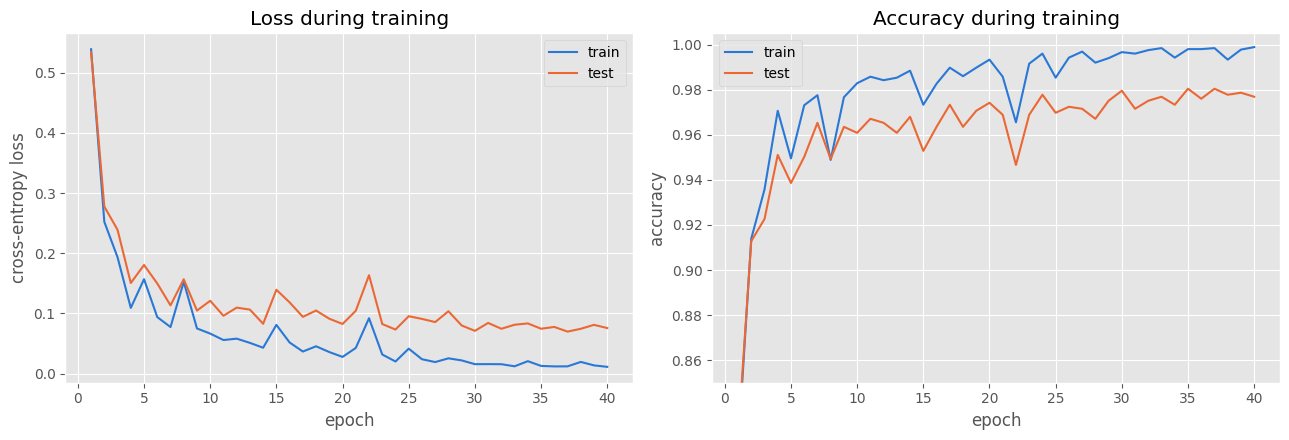

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(net.history['train_loss']) + 1)

ax[0].plot(epochs, net.history['train_loss'], color=blue, label='train')
ax[0].plot(epochs, net.history['test_loss'], color=orange, label='test')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('cross-entropy loss')
ax[0].set_title('Loss during training')
ax[0].legend()

ax[1].plot(epochs, net.history['train_acc'], color=blue, label='train')
ax[1].plot(epochs, net.history['test_acc'], color=orange, label='test')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.85, 1.005)
ax[1].set_title('Accuracy during training')
ax[1].legend()

plt.tight_layout()
plt.show()

## Removing the activation

The algebra above says a stack of affine layers is one affine layer. The cell tests it directly by
training three models on the same data:

- `net`, already trained, with ReLU between the layers.
- `linear_net`, the identical `[64, 64, 32, 10]` architecture with `activation=False`, so 6,570
  parameters arranged in three layers with nothing between them.
- `softmax_net`, a single `[64, 10]` layer, which is multinomial logistic regression on the raw
  pixels - the same model as Part 2 of the logistic regression notebook, with 650 parameters.

If the collapse argument holds, both linear models should settle at the accuracy a linear model can
reach and stay clearly below the ReLU network, and the deep one should get no representational
benefit from its extra 5,920 parameters.

In [8]:
linear_net = Neural_Network([64, 64, 32, 10], learning_rate=0.1, activation=False, seed=0)
linear_net.fit(X_train, y_train, X_test, y_test, epochs=40, batch_size=32, seed=0)

softmax_net = Neural_Network([64, 10], learning_rate=0.1, seed=0)
softmax_net.fit(X_train, y_train, X_test, y_test, epochs=40, batch_size=32, seed=0)

print(f'{"model":34s} {"weights":>9s} {"test acc":>10s}')
for name, model in [('ReLU [64, 64, 32, 10]', net),
                    ('linear [64, 64, 32, 10], no ReLU', linear_net),
                    ('linear [64, 10], softmax only', softmax_net)]:
    print(f'{name:34s} {model.weight_count():9d} {model.history["test_acc"][-1]:10.4f}')

model                                weights   test acc
ReLU [64, 64, 32, 10]                   6570     0.9769
linear [64, 64, 32, 10], no ReLU        6570     0.9635
linear [64, 10], softmax only            650     0.9555


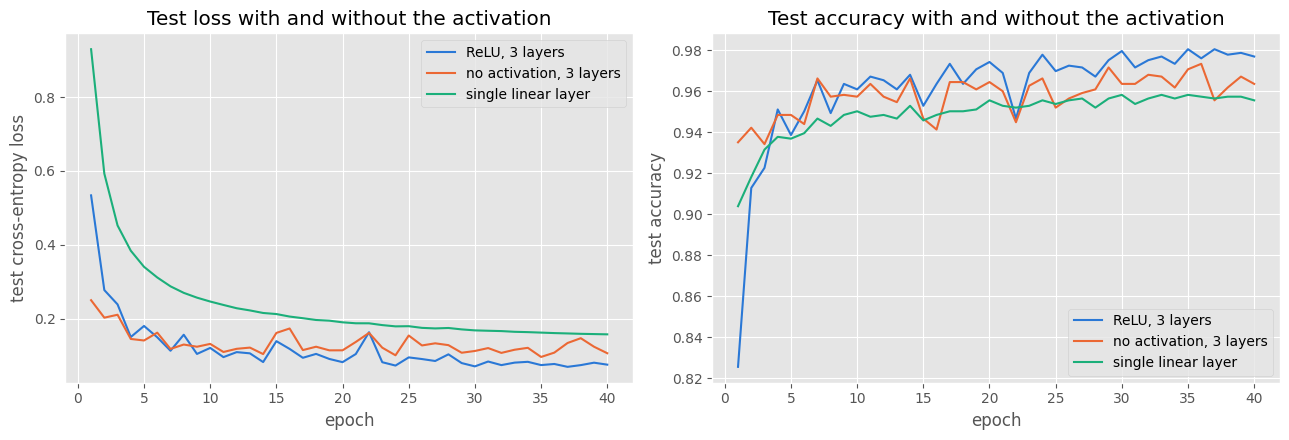

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, 41)

for model, colour, label in [(net, blue, 'ReLU, 3 layers'),
                             (linear_net, orange, 'no activation, 3 layers'),
                             (softmax_net, green, 'single linear layer')]:
    ax[0].plot(epochs, model.history['test_loss'], color=colour, label=label)
    ax[1].plot(epochs, model.history['test_acc'], color=colour, label=label)

ax[0].set_xlabel('epoch')
ax[0].set_ylabel('test cross-entropy loss')
ax[0].set_title('Test loss with and without the activation')
ax[0].legend()

ax[1].set_xlabel('epoch')
ax[1].set_ylabel('test accuracy')
ax[1].set_title('Test accuracy with and without the activation')
ax[1].legend()

plt.tight_layout()
plt.show()

Both linear models sit well below the ReLU network and neither improves with more epochs, while the
ReLU network with the same layer sizes is roughly two points higher. The two linear curves are not
identical: the three-layer version ends a little above the single layer. That difference is not
extra expressive power, it is optimisation. The product parameterisation $W_1W_2W_3$ rescales the
effective step size, so SGD moves faster through the same family of functions and its training loss
is lower after the same number of epochs.

The claim that the family really is the same can be checked exactly rather than argued from curves.
Multiplying the three trained weight matrices together gives a single $64 \times 10$ matrix, and
folding the biases through gives a single bias vector:

$$W' = W_1 W_2 W_3, \qquad \mathbf{b}' = \mathbf{b}_1 W_2 W_3 + \mathbf{b}_2 W_3 + \mathbf{b}_3$$

The cell below builds those two and compares the probabilities of the collapsed single-layer model
against the trained three-layer network on the whole test set.

In [10]:
W_collapsed = linear_net.weights[0] @ linear_net.weights[1] @ linear_net.weights[2]
b_collapsed = (linear_net.biases[0] @ linear_net.weights[1] @ linear_net.weights[2]
               + linear_net.biases[1] @ linear_net.weights[2]
               + linear_net.biases[2])

deep_probs = linear_net.forward(X_test)
collapsed_probs = softmax(X_test @ W_collapsed + b_collapsed)

print('three-layer parameters :', linear_net.weight_count())
print('collapsed parameters   :', W_collapsed.size + b_collapsed.size)
print('collapsed shape        :', W_collapsed.shape)
print('largest probability difference:', np.abs(deep_probs - collapsed_probs).max())
print('predictions identical  :', (deep_probs.argmax(axis=1) == collapsed_probs.argmax(axis=1)).all())

three-layer parameters : 6570
collapsed parameters   : 650
collapsed shape        : (64, 10)
largest probability difference: 3.1086244689504383e-15
predictions identical  : True


The difference is at the level of floating-point rounding. The 6,570-parameter network is a
650-parameter linear model written in a wasteful way - the extra 5,920 numbers are redundant
coordinates on the same function, not additional capacity. This is exactly what the activation
prevents: `np.maximum(0, z)` cannot be absorbed into a matrix product, so no such collapse exists
for the ReLU network.

## What universal approximation does and does not say

A network with a single hidden layer, a non-polynomial activation and enough hidden units can
approximate any continuous function on a compact set to within any $\varepsilon > 0$ in the
supremum norm. Formally, for continuous $f$ on compact $K \subset \mathbb{R}^d$ and any
$\varepsilon > 0$ there exist a width $m$ and parameters $W_1, \mathbf{b}_1, W_2, \mathbf{b}_2$
with

$$\sup_{\mathbf{x} \in K}
\left\| f(\mathbf{x}) - \left(W_2^\top g(W_1^\top\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2\right) \right\|
< \varepsilon$$

That is a statement about what the architecture can represent. It promises none of the following:

- **How many units.** $m$ is not bounded by the theorem, and for some functions it grows
  exponentially in the input dimension. "Enough units" can mean more than could ever be stored.
- **That training finds them.** The theorem says suitable weights exist. The loss surface here is
  non-convex and gradient descent has no guarantee of reaching a global minimum, so existence and
  reachability are separate questions.
- **That it generalises.** The approximation is over the training region, and a network with enough
  capacity to approximate any function also has enough capacity to fit noise exactly. Nothing in
  the theorem says anything about unseen data.
- **That depth is pointless.** One hidden layer suffices in principle, but for many functions a
  deeper network needs exponentially fewer units to reach the same accuracy.

So it rules out one particular excuse - the architecture being too weak to express the answer - and
nothing else. Everything that follows in this notebook is about the parts it does not cover.

## Effect of hidden-layer width

The cell trains a single-hidden-layer network `[64, w, 10]` for each width in 4, 8, 16, 32, 64,
128, 256, for 25 epochs. Because the loss is non-convex the result of any one run is partly luck,
so each width is trained from three seeds and the mean is what gets plotted, with the individual
runs drawn as dots so the spread is visible rather than hidden.

The left panel is test accuracy against width, the right is the parameter count, which grows as
$64w + w + 10w + 10 = 75w + 10$ and so is linear in the width. The two panels are separate rather
than sharing a twin axis, because accuracy and parameter count have nothing to do with each other
and overlaying them would invite reading a relationship off the crossing point.

Small widths underfit: 4 hidden units force all ten digits through a 4-dimensional bottleneck, and
no amount of training fixes that - it is also the noisiest setting, since with so little capacity
the initialisation decides a lot. Accuracy climbs steeply to 16 units and then flattens, so the
last doublings buy a fraction of a point each while doubling the weights every time.

In [11]:
widths = [4, 8, 16, 32, 64, 128, 256]
width_runs, width_params = [], []

for w in widths:
    runs = []
    for seed in range(3):
        model = Neural_Network([64, w, 10], learning_rate=0.1, seed=seed)
        model.fit(X_train, y_train, X_test, y_test, epochs=25, batch_size=32, seed=seed)
        runs.append(model.history['test_acc'][-1])
    width_runs.append(runs)
    width_params.append(model.weight_count())
    print(f'width {w:4d}  weights {model.weight_count():7d}  mean test accuracy {np.mean(runs):.4f}'
          f'  runs {[round(r, 4) for r in runs]}')

width    4  weights     310  mean test accuracy 0.8440  runs [0.8932, 0.7972, 0.8416]
width    8  weights     610  mean test accuracy 0.9404  runs [0.9404, 0.952, 0.9288]
width   16  weights    1210  mean test accuracy 0.9600  runs [0.9609, 0.9626, 0.9564]
width   32  weights    2410  mean test accuracy 0.9609  runs [0.9609, 0.9573, 0.9644]
width   64  weights    4810  mean test accuracy 0.9668  runs [0.9662, 0.9662, 0.968]
width  128  weights    9610  mean test accuracy 0.9689  runs [0.9662, 0.9689, 0.9715]
width  256  weights   19210  mean test accuracy 0.9709  runs [0.9689, 0.9689, 0.9751]


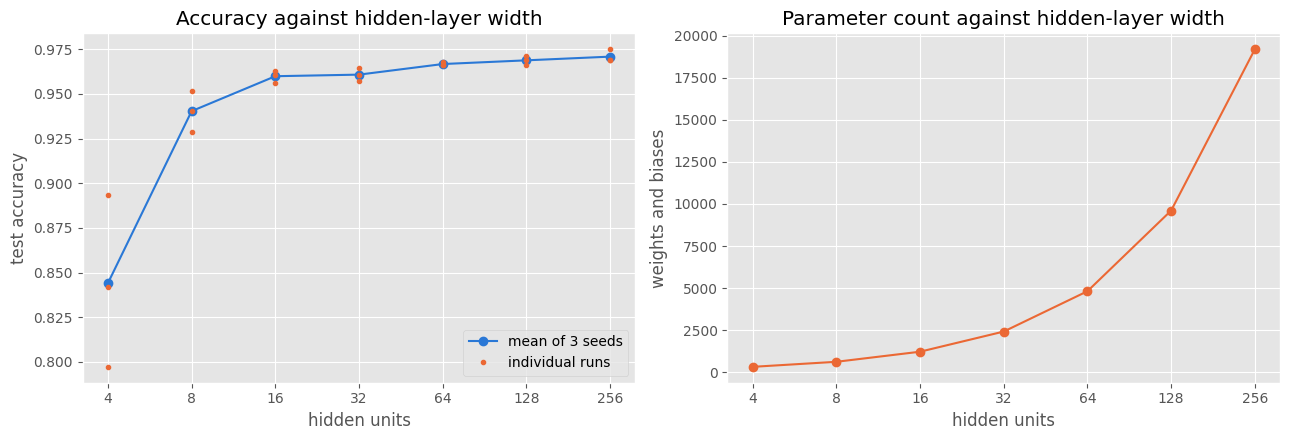

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

width_mean = [np.mean(r) for r in width_runs]

ax[0].plot(widths, width_mean, 'o-', color=blue, label='mean of 3 seeds')
for w, runs in zip(widths, width_runs):
    ax[0].plot([w] * len(runs), runs, '.', color=orange,
               label='individual runs' if w == widths[0] else None)
ax[0].set_xscale('log', base=2)
ax[0].set_xticks(widths)
ax[0].set_xticklabels(widths)
ax[0].set_xlabel('hidden units')
ax[0].set_ylabel('test accuracy')
ax[0].set_title('Accuracy against hidden-layer width')
ax[0].legend()

ax[1].plot(widths, width_params, 'o-', color=orange)
ax[1].set_xscale('log', base=2)
ax[1].set_xticks(widths)
ax[1].set_xticklabels(widths)
ax[1].set_xlabel('hidden units')
ax[1].set_ylabel('weights and biases')
ax[1].set_title('Parameter count against hidden-layer width')

plt.tight_layout()
plt.show()

## Effect of depth

The same comparison over the number of hidden layers, each of 64 units, again averaged over three
seeds at 25 epochs. Zero hidden layers is the linear softmax model, then 1, 2 and 3.

Going from 0 to 1 is where the non-linearity enters and it is worth over a point. The second hidden
layer adds most of another point, and the third adds very little on top of that while costing a
further 4,160 weights. The returns diminish sharply but they have not turned negative by three
layers - deeper is still slightly better here, just at a price that stops being worth paying.

In [13]:
depth_labels, depth_runs, depth_params = [], [], []

for hidden in range(4):
    sizes = [64] + [64] * hidden + [10]
    runs = []
    for seed in range(3):
        model = Neural_Network(sizes, learning_rate=0.1, seed=seed)
        model.fit(X_train, y_train, X_test, y_test, epochs=25, batch_size=32, seed=seed)
        runs.append(model.history['test_acc'][-1])
    depth_labels.append(hidden)
    depth_runs.append(runs)
    depth_params.append(model.weight_count())
    print(f'{hidden} hidden layers  {str(sizes):26s} weights {model.weight_count():6d}'
          f'  mean test accuracy {np.mean(runs):.4f}  runs {[round(r, 4) for r in runs]}')

0 hidden layers  [64, 10]                   weights    650  mean test accuracy 0.9540  runs [0.9537, 0.9528, 0.9555]
1 hidden layers  [64, 64, 10]               weights   4810  mean test accuracy 0.9668  runs [0.9662, 0.9662, 0.968]
2 hidden layers  [64, 64, 64, 10]           weights   8970  mean test accuracy 0.9757  runs [0.9778, 0.9724, 0.9769]
3 hidden layers  [64, 64, 64, 64, 10]       weights  13130  mean test accuracy 0.9772  runs [0.9786, 0.9795, 0.9733]


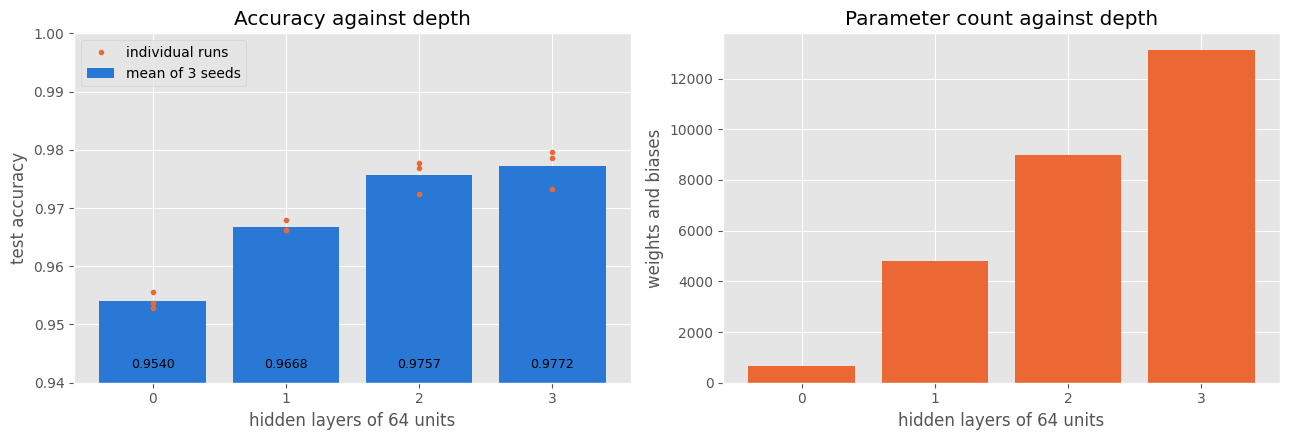

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

labels = [str(d) for d in depth_labels]
depth_mean = [np.mean(r) for r in depth_runs]

ax[0].bar(labels, depth_mean, color=blue, label='mean of 3 seeds')
for x, runs in enumerate(depth_runs):
    ax[0].plot([x] * len(runs), runs, '.', color=orange,
               label='individual runs' if x == 0 else None)
for x, v in enumerate(depth_mean):
    ax[0].text(x, 0.9425, f'{v:.4f}', ha='center', fontsize=9)
ax[0].set_ylim(0.94, 1.0)
ax[0].set_xlabel('hidden layers of 64 units')
ax[0].set_ylabel('test accuracy')
ax[0].set_title('Accuracy against depth')
ax[0].legend(loc='upper left')

ax[1].bar(labels, depth_params, color=orange)
ax[1].set_xlabel('hidden layers of 64 units')
ax[1].set_ylabel('weights and biases')
ax[1].set_title('Parameter count against depth')

plt.tight_layout()
plt.show()

## The loss surface is not convex

The linear and logistic regression notebooks both minimise a convex loss: there is one minimum, and
any run that converges converges to it. That is no longer true here. Swapping two hidden units,
along with their incoming and outgoing weights, leaves the network computing exactly the same
function, so every minimum comes with a large number of identical copies at different points in
parameter space, and the surface between them cannot be convex.

The practical consequence is that the starting point matters. The cell trains the same architecture
from five different seeds - which changes both the initial weights and the batch order - and prints
the final test accuracy of each. They land in different places. The spread is small here because
the problem is easy, but it is real, and it means a single reported accuracy is a sample rather than
a property of the architecture.

In [15]:
seed_acc = []

for seed in range(5):
    model = Neural_Network([64, 64, 32, 10], learning_rate=0.1, seed=seed)
    model.fit(X_train, y_train, X_test, y_test, epochs=25, batch_size=32, seed=seed)
    seed_acc.append(model.history['test_acc'][-1])
    print(f'seed {seed}  final train loss {model.history["train_loss"][-1]:.4f}'
          f'  test accuracy {seed_acc[-1]:.4f}')

print()
print(f'spread: {min(seed_acc):.4f} to {max(seed_acc):.4f}, '
      f'mean {np.mean(seed_acc):.4f}, std {np.std(seed_acc):.4f}')

seed 0  final train loss 0.0414  test accuracy 0.9698
seed 1  final train loss 0.0260  test accuracy 0.9680
seed 2  final train loss 0.0256  test accuracy 0.9724
seed 3  final train loss 0.0255  test accuracy 0.9733
seed 4  final train loss 0.0257  test accuracy 0.9733

spread: 0.9680 to 0.9733, mean 0.9714, std 0.0021


## What the first layer learned

Each of the 64 hidden units in the first layer has 64 incoming weights, one per pixel, so a column
of `net.weights[0]` can be reshaped straight back into an 8x8 grid and drawn. Light squares are
positive weights, dark are negative, and a unit responds most strongly to an image that looks like
its picture.

Several come out with visible stroke-like structure - a bright diagonal, a ring, a bar across the
top. But look at what these are: each one is a template covering the **whole image**, tied to
absolute pixel positions. A unit that has learned to detect a vertical stroke on the left side of
the image knows nothing about a vertical stroke on the right; a separate unit has to learn that
independently, from separate examples, with its own 64 weights.

This is the exact difference from the CNN notebook. There a filter is 3x3 - 9 weights - and the
same 9 weights are applied at all 36 positions, so one filter detects its pattern anywhere in the
image and every training example that contains that pattern anywhere contributes to learning it.
The MLP has to rediscover the same stroke separately at each location it appears. That is what
throwing away adjacency costs, and it is why the CNN gets comparable accuracy from a quarter as
many weights.

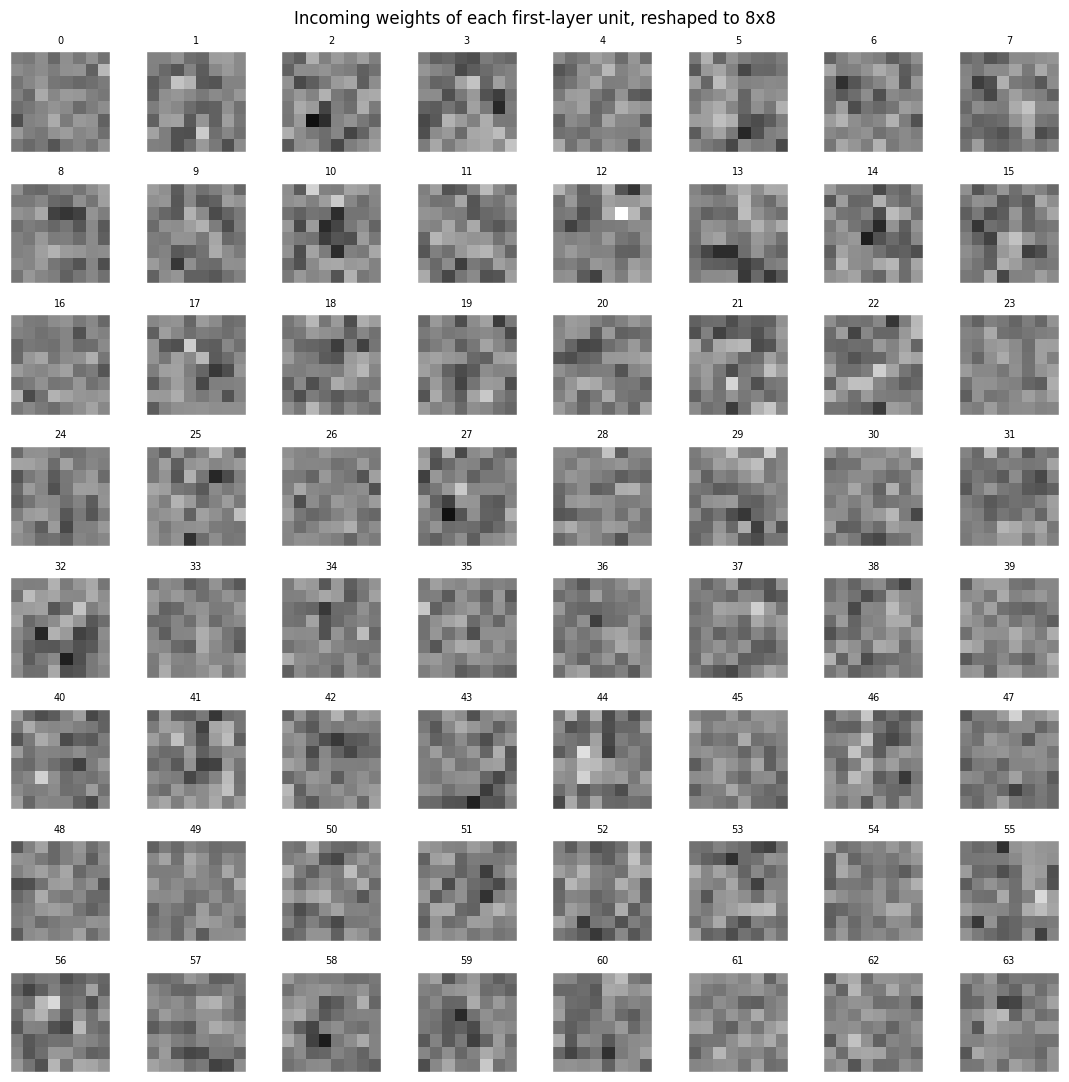

In [16]:
fig, ax = plt.subplots(8, 8, figsize=(11, 11))

limit = np.abs(net.weights[0]).max()
for unit, a in enumerate(ax.ravel()):
    a.imshow(net.weights[0][:, unit].reshape(8, 8), cmap='gray_r', vmin=-limit, vmax=limit)
    a.set_title(f'{unit}', fontsize=7)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

plt.suptitle('Incoming weights of each first-layer unit, reshaped to 8x8')
plt.tight_layout()
plt.show()

## Where the mistakes are

The table counts every test digit by what it was against what the network said, so the diagonal is
the correct answers and everything off it is an error. The cell also prints the most frequent
confusions.

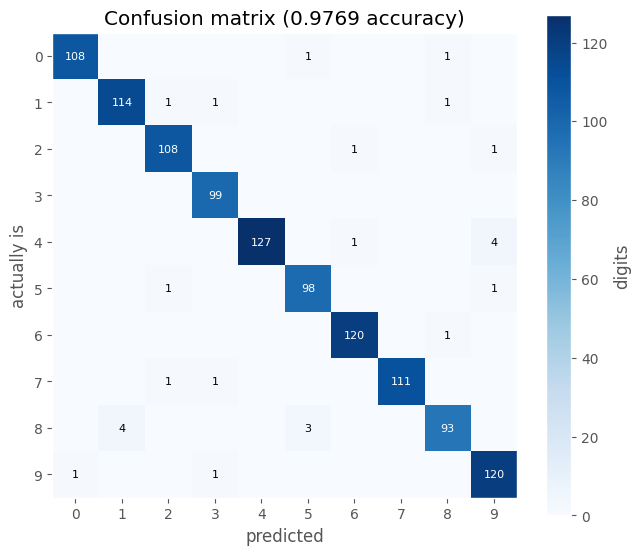

most common mix-ups:
  8 called 1: 4 times
  4 called 9: 4 times
  8 called 5: 3 times
  9 called 3: 1 times
  9 called 0: 1 times


In [17]:
predictions = net.predict(X_test)

table = np.zeros((10, 10), dtype=int)
for true, guess in zip(y_test, predictions):
    table[true, guess] += 1

plt.figure(figsize=(7.5, 6.5))
plt.imshow(table, cmap='Blues')
for i in range(10):
    for j in range(10):
        if table[i, j] > 0:
            plt.text(j, i, table[i, j], ha='center', va='center', fontsize=8,
                     color='white' if table[i, j] > table.max() / 2 else 'black')
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel('predicted')
plt.ylabel('actually is')
plt.title(f'Confusion matrix ({(predictions == y_test).mean():.4f} accuracy)')
plt.colorbar(label='digits')
plt.grid(False)
plt.show()

confused = [(table[i, j], i, j) for i in range(10) for j in range(10) if i != j]
print('most common mix-ups:')
for count, true, guess in sorted(confused, reverse=True)[:5]:
    print(f'  {true} called {guess}: {count} times')

The digits it gets wrong, with the true label and the guess, and the probability the network gave
its answer. Most are ambiguous at 8x8 resolution, and the confidence on them is often low, which is
the network reporting the ambiguity rather than being confidently wrong.

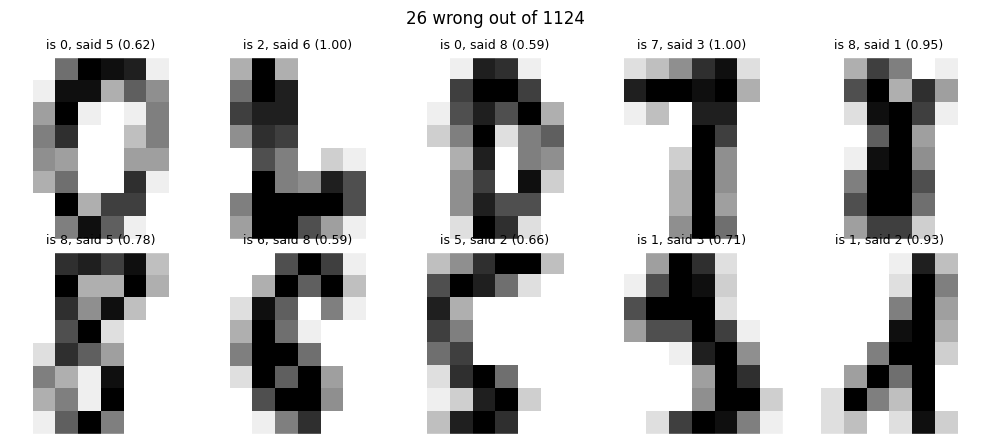

In [18]:
wrong = np.where(predictions != y_test)[0][:10]
probs_test = net.forward(X_test)

fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, index in zip(ax.ravel(), wrong):
    a.imshow(X_images[test_idx[index]], cmap='gray_r')
    a.set_title(f'is {y_test[index]}, said {predictions[index]}'
                f' ({probs_test[index].max():.2f})', fontsize=9)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

for a in ax.ravel()[len(wrong):]:
    a.axis('off')

plt.suptitle(f'{(predictions != y_test).sum()} wrong out of {len(y_test)}')
plt.tight_layout()
plt.show()

## Against the convolutional network

The cell puts this network next to the CNN from `2d_cnn_from_scratch.ipynb`, which reached 97.9% on
the same test split from 1,610 weights, and next to the deepest network in the depth sweep. It also
reports the total runtime of the notebook.

In [19]:
mlp_acc = net.history['test_acc'][-1]
mlp_weights = net.weight_count()
deep_acc, deep_weights = depth_mean[-1], depth_params[-1]

print(f'{"model":34s} {"weights":>9s} {"test accuracy":>15s}')
print(f'{"MLP [64, 64, 32, 10]":34s} {mlp_weights:9d} {mlp_acc:15.4f}')
print(f'{"MLP, 3 hidden layers of 64":34s} {deep_weights:9d} {deep_acc:15.4f}')
print(f'{"CNN, 16 filters of 3x3":34s} {1610:9d} {0.979:15.4f}')
print()
print(f'the MLP uses {mlp_weights / 1610:.1f}x the weights of the CNN'
      f' for {mlp_acc - 0.979:+.4f} accuracy')
print(f'the deeper MLP uses {deep_weights / 1610:.1f}x'
      f' for {deep_acc - 0.979:+.4f}')
print()
print(f'total notebook runtime: {time.time() - notebook_start:.1f} s')

model                                weights   test accuracy
MLP [64, 64, 32, 10]                    6570          0.9769
MLP, 3 hidden layers of 64             13130          0.9772
CNN, 16 filters of 3x3                  1610          0.9790

the MLP uses 4.1x the weights of the CNN for -0.0021 accuracy
the deeper MLP uses 8.2x for -0.0018

total notebook runtime: 1424.2 s


The MLP lands within a few tenths of a point of the CNN and needs four times the weights to do it;
adding hidden layers closes the gap but multiplies the cost again. Neither model is simply better.
The CNN wins on weights because of two assumptions built into its architecture - that useful
patterns are local, so a unit only needs to look at a 3x3 patch, and that a pattern means the same
thing wherever it appears, so one set of 9 weights can be reused at all 36 positions. Both
assumptions are true of images, and neither is available to a network that receives the image as 64
unordered numbers.

The MLP pays for that in parameters, but it makes no assumption in return. The same class, with the
same code, runs on any table of features where no such spatial structure exists, which is where the
convolutional architecture would have nothing to exploit.

## Summary

- A multilayer perceptron alternates $\mathbf{z}^{(l)} = W^{(l)\top}\mathbf{a}^{(l-1)} +
  \mathbf{b}^{(l)}$ with an elementwise non-linearity, and finishes with a softmax over 10 scores.
- Backpropagation is one recurrence, $\boldsymbol\delta^{(l)} = (W^{(l+1)}\boldsymbol\delta^{(l+1)})
  \odot g'(\mathbf{z}^{(l)})$, started from $\boldsymbol\delta^{(L)} = \mathbf{p} - \mathbf{y}$,
  with $\partial J/\partial W^{(l)} = \mathbf{a}^{(l-1)}\boldsymbol\delta^{(l)\top}$. Written as a
  loop over layers in reverse it is about ten lines, and it is the same idea the CNN notebook
  applies to convolution and pooling.
- The finite-difference check confirms every gradient to eight decimal places before any training
  is done.
- He initialisation, $\sigma = \sqrt{2/n_{\text{in}}}$, keeps the variance of the signal steady
  across layers so it neither vanishes nor explodes with depth; zero initialisation would leave
  every unit in a layer identical forever.
- Deleting the activation drops the network to linear-model accuracy, and multiplying the three
  trained matrices together reproduces its probabilities to within $10^{-15}$ - the 6,570-parameter
  network is a 650-parameter linear model in disguise, exactly as
  $W_2^\top(W_1^\top\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = W'^\top\mathbf{x} + \mathbf{b}'$
  says it must be.
- Width helps steeply up to about 16 units and then flattens. Depth helps by a shrinking amount per
  layer: the first is worth over a point, the third almost nothing for 4,160 extra weights. The
  universal approximation theorem covers only what the architecture can represent, and says nothing
  about how many units are needed, whether SGD will find them, or whether the result generalises.
- The loss is non-convex, unlike linear and logistic regression, so different seeds finish at
  different accuracies and any single number quoted is one sample from that spread.
- Against the CNN: the MLP gets close on accuracy while spending several times the weights. The
  first-layer pictures show why. They are whole-image templates fixed to absolute pixel positions,
  so the same stroke in a different place needs a different unit, while the CNN's 3x3 filters are
  reused at every position and so cost 9 weights each regardless of where the pattern appears.
  Flattening the image is what throws that away.